# Bayesian Logistic Regression 
Includes comparisons, ROC curve, and visualizations.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="muted")

## Load Data

In [15]:
df = pd.read_csv('weatherAUS.csv')
df.columns = df.columns.str.strip()
df['RainTomorrow'] = df['Precip Type'].apply(lambda x: 1 if str(x).lower() == 'rain' else 0)

features = ['Temperature (C)','Apparent Temperature (C)','Humidity','Wind Speed (km/h)','Visibility (km)','Pressure (millibars)']
df = df[features + ['RainTomorrow']].dropna()

## Prepare Data

In [16]:
X = df[features].values
y = df['RainTomorrow'].values
X = (X - X.mean(axis=0)) / X.std(axis=0)
X = np.hstack([np.ones((X.shape[0],1)), X])

np.random.seed(42)
idx = np.random.permutation(len(X))
split = int(0.8*len(X))
X_train, X_test = X[idx[:split]], X[idx[split:]]
y_train, y_test = y[idx[:split]], y[idx[split:]]

## Models

In [17]:
def sigmoid(z):
    z = np.clip(z,-500,500)
    return 1/(1+np.exp(-z))

def train_logistic(X,y,lr=0.001,epochs=1000):
    beta = np.zeros(X.shape[1])
    for _ in range(epochs):
        p = sigmoid(X@beta)
        beta += lr * (X.T@(y-p))
    return beta

def train_bayesian(X,y,lr=0.001,epochs=1000,sigma2=0.5):
    beta = np.zeros(X.shape[1])
    for _ in range(epochs):
        p = sigmoid(X@beta)
        grad = X.T@(y-p) - (1/sigma2)*beta
        beta += lr*grad
    return beta

def predict_proba(X,b): return sigmoid(X@b)
def predict(X,b): return (predict_proba(X,b)>=0.5).astype(int)

## Train Models

In [18]:
beta_log = train_logistic(X_train,y_train)
beta_bayes = train_bayesian(X_train,y_train)

## Accuracy Comparison

In [19]:
acc_log = np.mean(predict(X_test,beta_log)==y_test)
acc_bayes = np.mean(predict(X_test,beta_bayes)==y_test)
print('Logistic:',acc_log)
print('Bayesian:',acc_bayes)

Logistic: 0.9458814991446789
Bayesian: 0.9374838007360945


## Coefficients (Bayesian)

Intercept 59.3674
Temperature (C) 32.2273
Apparent Temperature (C) 9.2381
Humidity 5.6674
Wind Speed (km/h) 2.0382
Visibility (km) -0.3547
Pressure (millibars) -0.3811


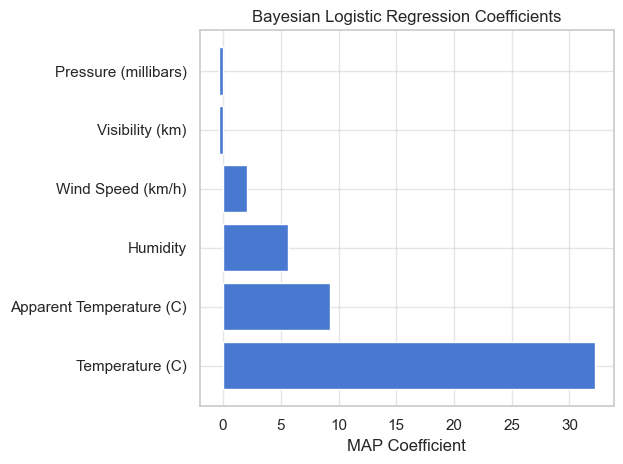

In [20]:
names=['Intercept']+features
for n,c in zip(names,beta_bayes): print(n,round(c,4))

coef_names = features
coef_vals = beta_bayes[1:]  # skip intercept
plt.barh(coef_names, coef_vals)
plt.xlabel('MAP Coefficient')
plt.title('Bayesian Logistic Regression Coefficients')
plt.tight_layout()
plt.savefig('bayes_coefs.png', dpi=150)

## Probability Histogram

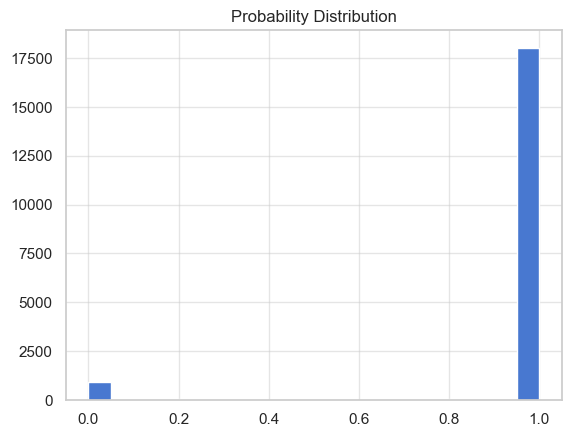

In [21]:
probs = predict_proba(X_test,beta_bayes)
plt.hist(probs,bins=20)
plt.title('Probability Distribution')
plt.show()

## Humidity vs Probability

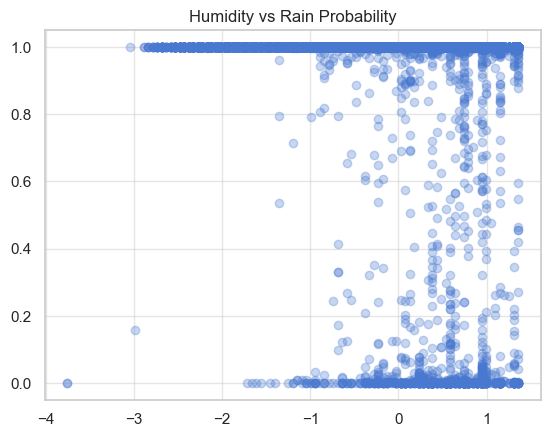

In [22]:
i=features.index('Humidity')
plt.scatter(X_test[:,i+1],probs,alpha=0.3)
plt.title('Humidity vs Rain Probability')
plt.show()

## ROC Curve

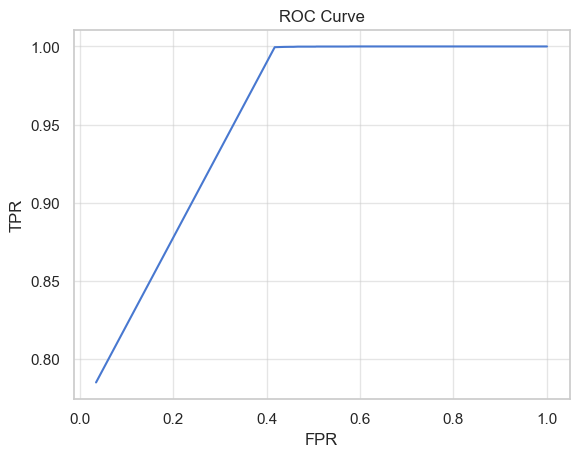

In [23]:
thresholds = np.linspace(0,1,50)
tpr=[]; fpr=[]
for t in thresholds:
    pred=(probs>=t).astype(int)
    TP=np.sum((pred==1)&(y_test==1))
    FP=np.sum((pred==1)&(y_test==0))
    FN=np.sum((pred==0)&(y_test==1))
    TN=np.sum((pred==0)&(y_test==0))
    tpr.append(TP/(TP+FN+1e-9))
    fpr.append(FP/(FP+TN+1e-9))

plt.plot(fpr,tpr)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.show()

## Accuracy Bar Chart

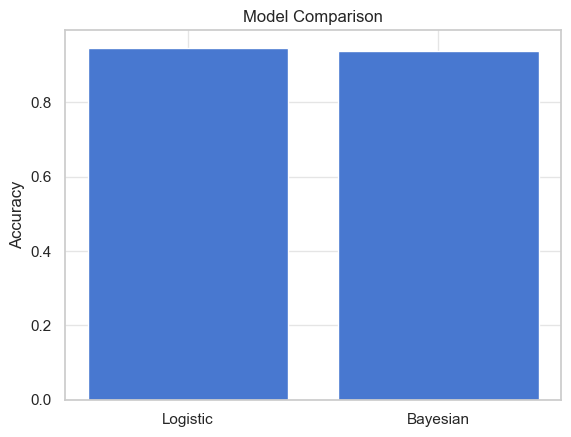

In [24]:
plt.bar(['Logistic','Bayesian'],[acc_log,acc_bayes])
plt.title('Model Comparison')
plt.ylabel('Accuracy')
plt.show()

The high predictive accuracy and strong ROC performance suggest that the model effectively captures relationships between atmospheric variables and precipitation. However, since the dataset doesn't contain a true next day rainfall label, the problem is simplified to predicting current precipitation, which likely inflates performance relative to real-world forecasting tasks.